In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("../data/tb_cust.csv")
transactions = pd.read_csv("../data/tb_transaction.csv")
products = pd.read_csv("../data/tb_transaction_product.csv")
fees = pd.read_csv("../data/tb_transaction_fees.csv")

In [3]:
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [4]:
transactions["amount"].describe()

count    2.000000e+05
mean     3.075336e+05
std      3.430042e+05
min      1.000000e+04
25%      1.168142e+05
50%      2.035073e+05
75%      3.678785e+05
max      1.000000e+07
Name: amount, dtype: float64

In [5]:
transaction_type = (
    transactions["transaction_type"]
    .value_counts()
)

transaction_type

transaction_type
Shopping Payment    120203
Bank Transfer        79797
Name: count, dtype: int64

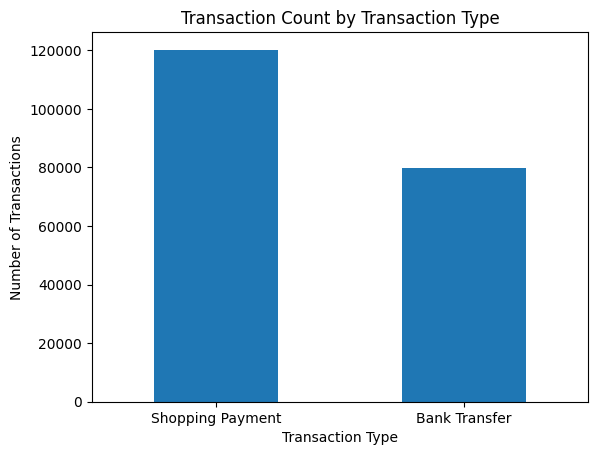

In [6]:
transaction_type.plot(
    kind="bar",
    title="Transaction Count by Transaction Type"
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

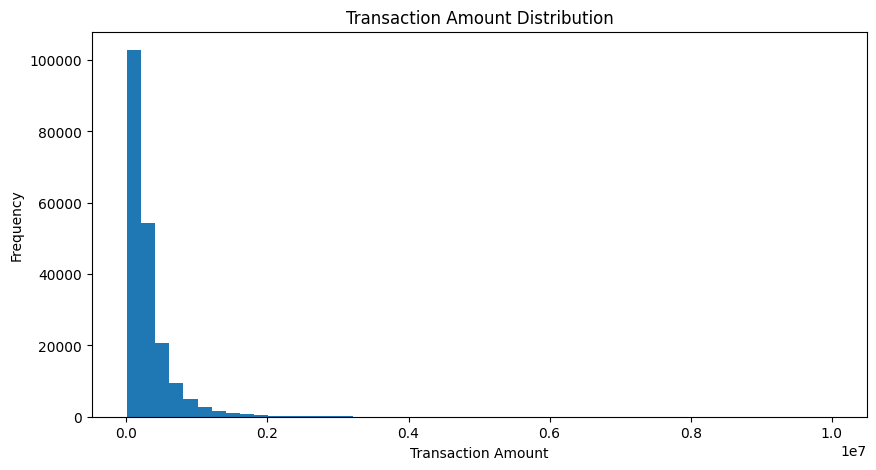

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    transactions["amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [8]:
transactions["month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

In [9]:
monthly_transactions = (
    transactions
    .groupby("month")
    .size()
)

monthly_transactions

month
2025-01    11381
2025-02    10171
2025-03    11520
2025-04    10983
2025-05    11498
2025-06    10750
2025-07    11288
2025-08    11471
2025-09    11068
2025-10    11296
2025-11    11051
2025-12    11430
2026-01    11357
2026-02    10312
2026-03    11224
2026-04    11052
2026-05    11308
2026-06    10840
Freq: M, dtype: int64

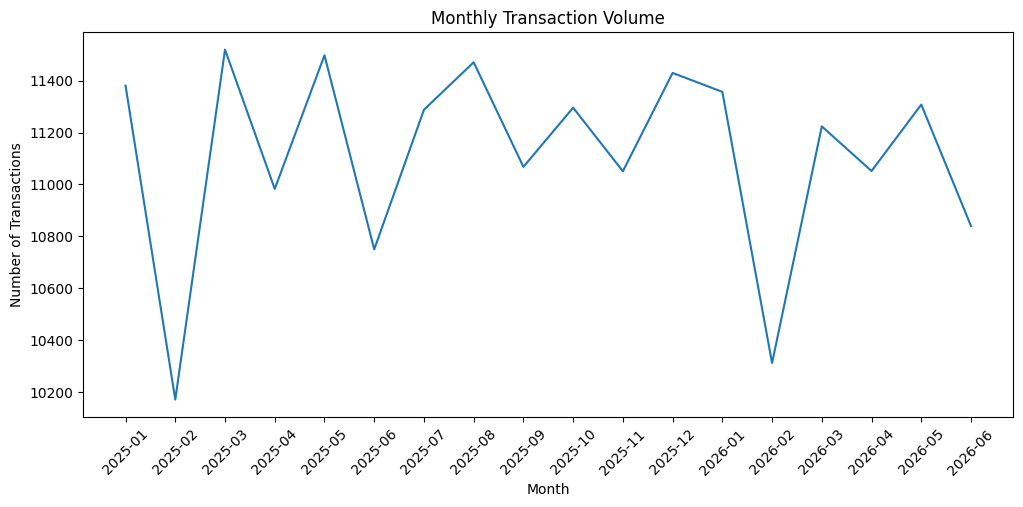

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [11]:
transaction_revenue = transactions.merge(
    fees[[
        "transaction_id",
        "fee_percentage",
        "fee_amount"
    ]],
    on="transaction_id",
    how="left"
)

In [12]:
transaction_revenue.head()

,transaction_id,customer_id,transaction_date,transaction_type,amount,month,fee_percentage,fee_amount
0,65729,3302,2025-01-01,Bank Transfer,271040.36,2025-01,0.5,1355.20
1,100855,8069,2025-01-01,Bank Transfer,389439.44,2025-01,0.5,1947.20
2,43254,4752,2025-01-01,Shopping Payment,74162.57,2025-01,1.0,741.63
3,43050,6521,2025-01-01,Bank Transfer,141149.29,2025-01,0.5,705.75
4,46190,1833,2025-01-01,Shopping Payment,696860.92,2025-01,1.0,6968.61


In [13]:
transaction_revenue["fee_amount"].describe()

count    200000.000000
mean       2113.796972
std        1881.175504
min          50.000000
25%         965.477500
50%        1589.430000
75%        2621.397500
max       50000.000000
Name: fee_amount, dtype: float64

In [14]:
total_revenue = transaction_revenue["fee_amount"].sum()

print(f"Total Revenue: Rp {total_revenue:,.0f}")

Total Revenue: Rp 422,759,394


In [15]:
monthly_revenue = (
    transaction_revenue
    .groupby("month")["fee_amount"]
    .sum()
)

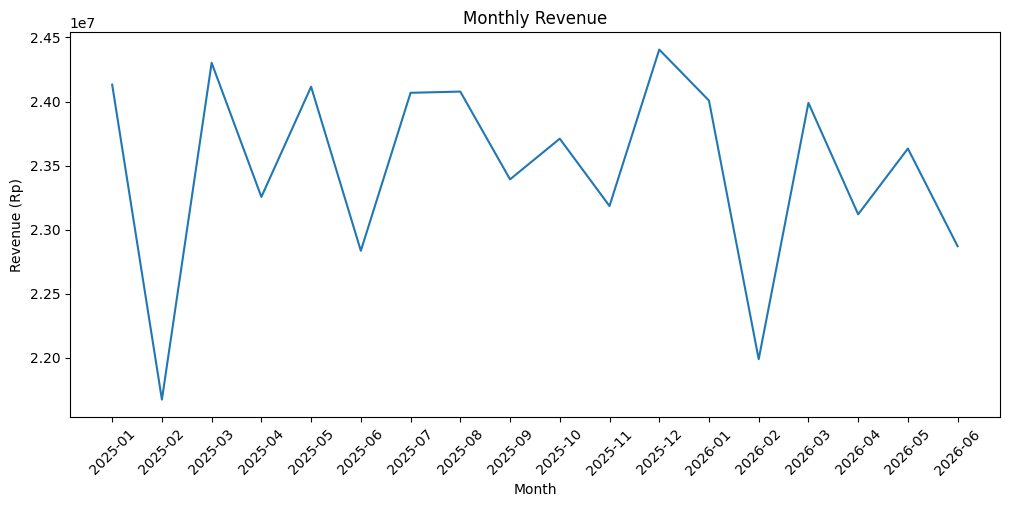

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (Rp)")

plt.xticks(rotation=45)

plt.show()